In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils_lstm import LSTMAttentionModel, train_model, evaluate_model, plot_importance, sliding_window_importance
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
targets

In [ ]:
angle = 45
experiment = 3
# Collect the 6th row's Main-axis value per experiment
selected = []
for exp_id, group in targets.groupby("Experiment_ID"):
    if len(group) > 6:  
        value = group.iloc[angle] # 6th row by position
    else:
        value = np.nan  # if experiment shorter than 7 rows
    selected.append([value])  # wrap in list → keeps (num_experiments, 1)

y = np.array(selected, dtype=float)[:,0,1:]
y = np.array(y)
groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)

X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)
y = np.nan_to_num(y, nan=0.0)
print("Shape:", X.shape, y.shape)  
# Convert to tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

Shape: (315, 1743, 17) (315, 47, 5)


In [ ]:
model = LSTMAttentionModel(input_size=17, hidden_size=32, output_size=5, dropout=0.3)
model = train_model(model, X_tensor, y_tensor, epochs=5, lr=0.001, batch_size=32, print_every=1)

Training:  16%|█▌        | 81/500 [03:02<15:46,  2.26s/epoch, avg_loss=0.00411876]


KeyboardInterrupt: 

In [ ]:
# Evaluate
output, attn_weights, loss_val = evaluate_model(model, X_tensor, y_tensor)

# Sliding window importance (optional)
importance_scores = sliding_window_importance(model, X_tensor[0], y_tensor[0], window_size=10, stride=5)


Final Loss: 0.02099085
Predicted: [[-1.0976538e-02  3.9852571e-01  4.2904854e-01  5.7156736e-01
   4.0878606e-01]
 [-1.0819346e-02  3.9968157e-01  4.3051982e-01  5.7098585e-01
   4.1127276e-01]
 [-1.1502728e-02  3.9912465e-01  4.2775533e-01  5.6796628e-01
   4.0956244e-01]
 ...
 [-5.6717843e-03  5.2911395e-01  5.1365876e-01  5.0559717e-01
   5.2253807e-01]
 [ 1.2817996e-04  5.2698731e-01  5.1110244e-01  4.9707347e-01
   5.0434625e-01]
 [ 3.1745451e-04  5.2691126e-01  5.1049793e-01  4.9655712e-01
   5.0340575e-01]]
Target: [[0.         0.31746134 0.33704993 0.62603366 0.34454256]
 [0.         0.42513746 0.40812522 0.58348256 0.3817239 ]
 [0.         0.3049661  0.35883358 0.5999486  0.3609504 ]
 ...
 [0.         0.5396207  0.5605501  0.46089754 0.5283486 ]
 [0.         0.5438669  0.57666045 0.44567245 0.54192674]
 [0.         0.6540088  0.57715535 0.47669396 0.5314483 ]]
Baseline Prediction: tensor([[-0.0110,  0.3985,  0.4290,  0.5716,  0.4088]])
Target: tensor([0.0000, 0.3175, 0.3370, 0

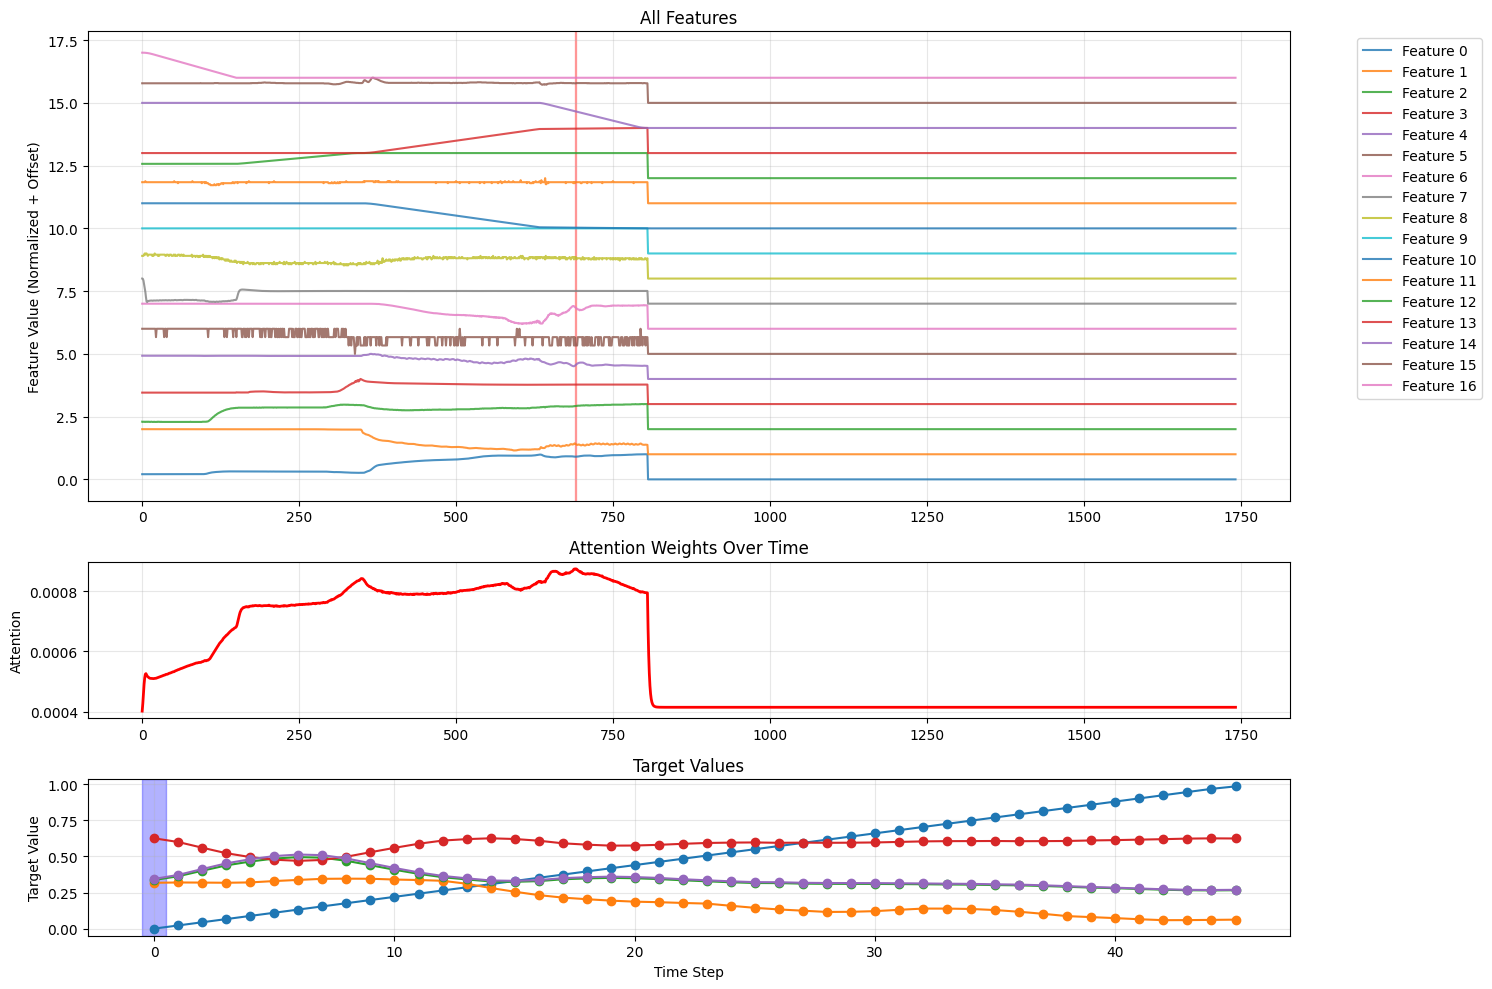

In [ ]:
experiment_id = 2
target = targets[targets["Experiment_ID"]==experiment_id].iloc[:, 1:]
# Plot results with highest-attended area highlighted
plot_importance(X[experiment_id-2], scores=importance_scores, target=target, attn_weights=attn_weights[experiment_id-2],top_n=10, target_angle=angle)